<a href="https://colab.research.google.com/github/mbalungilenkosingiphile-art/Steel-Surface-Detect-/blob/main/Task2_Baseline_CNN_SteelDefect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Metal Surface (Steel) Defect Classifier
## Task 2 — Baseline Model, Training Logs & Evaluation

**Group 10** — Reentseng Mokoena, Thembelani Mkhulise, Khulasande Gwamanda, Balungile Mdlalose

This notebook implements **Week 2** of the work plan:
> *Preprocess data, train a simple CNN from scratch, record baseline accuracy — output: baseline results + confusion matrix.*

**How to use this notebook**
1. Run every cell top to bottom in **Google Colab** (Runtime → Change runtime type → GPU is optional but faster).
2. Section 1 downloads the NEU-CLS dataset automatically. If the automatic download fails (Kaggle credentials, network, etc.), instructions for a manual fallback are printed.
3. Section 4 trains a **baseline CNN built from scratch** (no pretrained weights) — this establishes the floor accuracy your Week 3 transfer-learning model needs to beat.
4. Section 5 evaluates the baseline on the held-out test split: accuracy, per-class precision/recall/F1, and a confusion matrix — screenshot these for your report.
5. Training logs (per-epoch loss/accuracy) and the trained baseline weights are saved to disk so you can reload them later.


## 1. Setup

In [ ]:
# Core packages (torch/torchvision/sklearn/matplotlib are pre-installed on Colab).
# kagglehub is the easiest way to pull the NEU Surface Defect Database without manual uploads.
!pip install -q kagglehub scikit-learn seaborn


In [ ]:
import os, io, json, time, random, shutil, zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


## 2. Download the NEU-CLS dataset

We use the **classification-only** version of the NEU Surface Defect Database (NEU-CLS): 1,800 grayscale
200x200 images, 300 per class, across 6 classes (crazing, inclusion, patches, pitted_surface,
rolled-in_scale, scratches) — matching the dataset summary from Task 1.

The cell below tries `kagglehub` first (no login needed for most public datasets on Colab).
If it fails in your environment, use the **manual fallback**: download the dataset yourself,
zip it so each class has its own subfolder, upload the zip to Colab, and set `MANUAL_ZIP_PATH` below.


In [ ]:
RAW_DIR = Path("/content/neu_raw")
DATA_DIR = Path("/content/NEU-CLS")  # final ImageFolder-ready layout: DATA_DIR/<class_name>/*.jpg

MANUAL_ZIP_PATH = None  # e.g. "/content/NEU-CLS.zip" if you upload the dataset yourself

def try_kagglehub_download():
    import kagglehub
    # Public Kaggle mirror of the NEU surface defect database.
    path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")
    return Path(path)

def build_dataset_folder(source_root: Path):
    """Walk the downloaded dataset and re-organise it into DATA_DIR/<class>/<image>."""
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    class_names = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]
    # normalise how classes might be spelled in the source (case/underscore/hyphen variants)
    def norm(s):
        return s.lower().replace(" ", "_").replace("-", "_")
    target_by_norm = {norm(c): c for c in class_names}

    found = 0
    for img_path in source_root.rglob("*"):
        if img_path.suffix.lower() not in (".bmp", ".jpg", ".jpeg", ".png"):
            continue
        stem = norm(img_path.stem.rsplit("_", 1)[0]) if "_" in img_path.stem else norm(img_path.parent.name)
        # try filename prefix first (NEU-CLS files are named like crazing_1.bmp), else parent folder name
        cls = None
        for key, orig in target_by_norm.items():
            if img_path.stem.lower().startswith(key.split("_")[0]) and key in norm(img_path.stem):
                cls = orig
                break
        if cls is None:
            cls = target_by_norm.get(norm(img_path.parent.name))
        if cls is None:
            continue
        dest_dir = DATA_DIR / cls
        dest_dir.mkdir(parents=True, exist_ok=True)
        dest = dest_dir / img_path.name
        if not dest.exists():
            shutil.copy(img_path, dest)
        found += 1
    return found

if MANUAL_ZIP_PATH:
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(MANUAL_ZIP_PATH) as zf:
        zf.extractall(RAW_DIR)
    n = build_dataset_folder(RAW_DIR)
    print(f"Manual upload processed: {n} images copied into {DATA_DIR}")
else:
    try:
        src = try_kagglehub_download()
        n = build_dataset_folder(src)
        print(f"kagglehub download processed: {n} images copied into {DATA_DIR}")
    except Exception as e:
        print("Automatic download failed:", e)
        print("""
MANUAL FALLBACK:
1. Download the NEU Surface Defect Database (NEU-CLS) from Kaggle or the official NEU source.
2. Zip it so it contains one folder per class (crazing, inclusion, patches, pitted_surface,
   rolled-in_scale, scratches), each holding that class's images.
3. Upload the zip to Colab (left sidebar -> Files -> upload).
4. Set MANUAL_ZIP_PATH = \"/content/your_file.zip\" above and re-run this cell.
""")


Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
kagglehub download processed: 1800 images copied into /content/NEU-CLS


In [ ]:
# Verify class balance (should be 300 images per class, 1800 total, per Task 1 dataset summary)
assert DATA_DIR.exists(), "DATA_DIR was not populated — see the manual fallback instructions above."

counts = {}
for cls_dir in sorted(DATA_DIR.iterdir()):
    if cls_dir.is_dir():
        counts[cls_dir.name] = len(list(cls_dir.glob("*")))

print("Per-class image counts:")
for k, v in counts.items():
    print(f"  {k:16s} {v}")
print("Total:", sum(counts.values()))


Per-class image counts:
  crazing          300
  inclusion        300
  patches          300
  pitted_surface   300
  rolled-in_scale  300
  scratches        300
Total: 1800


## 3. Preprocessing and stratified 70/15/15 split

Following the Task 1 preprocessing plan:
- grayscale → 3-channel RGB
- resize to 224x224
- normalize to ImageNet mean/std
- **stratified** 70% train / 15% validation / 15% test split (stratified so each split keeps the class balance)
- light augmentation on the training split only (random rotation, horizontal flip, random zoom via resized crop)


In [ ]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),   # random "zoom"
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Two ImageFolder views over the same files: one with train-time augmentation, one without.
base_dataset_train_view = datasets.ImageFolder(DATA_DIR, transform=train_transform)
base_dataset_eval_view = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

class_names = base_dataset_train_view.classes
print("Classes:", class_names)

targets = np.array(base_dataset_train_view.targets)
indices = np.arange(len(targets))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=targets, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=SEED
)

print(f"Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}")

train_ds = Subset(base_dataset_train_view, train_idx)   # augmented
val_ds = Subset(base_dataset_eval_view, val_idx)         # clean
test_ds = Subset(base_dataset_eval_view, test_idx)       # clean

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Train: 1260  Val: 270  Test: 270


## 4. Baseline CNN (trained from scratch)

A small convolutional network with **no pretrained weights** — this is the Week 2 baseline that the
Week 3 transfer-learning model (ResNet18 / MobileNetV2) must beat.


In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 224 -> 112
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 112 -> 56
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 28 -> 14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=len(class_names)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {n_params:,}")


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

NUM_EPOCHS = 25
EARLY_STOP_PATIENCE = 7


In [ ]:
def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_n += images.size(0)
    return total_loss / total_n, total_correct / total_n


In [ ]:
history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
epochs_no_improve = 0

print(f"{'Epoch':>5} | {'train_loss':>10} | {'train_acc':>9} | {'val_loss':>8} | {'val_acc':>7}")
print("-" * 55)

t0 = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"{epoch:5d} | {train_loss:10.4f} | {train_acc:9.4f} | {val_loss:8.4f} | {val_acc:7.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch} (no val improvement for {EARLY_STOP_PATIENCE} epochs).")
            break

elapsed = time.time() - t0
print(f"\nTraining finished in {elapsed/60:.1f} min. Best val loss: {best_val_loss:.4f}")

# restore best-epoch weights before evaluating on the test set
if best_state is not None:
    model.load_state_dict(best_state)


Epoch | train_loss | train_acc | val_loss | val_acc
-------------------------------------------------------
    1 |     1.2784 |    0.5286 |   1.2786 |  0.3926
    2 |     0.7713 |    0.7095 |   0.6173 |  0.7185
    3 |     0.6118 |    0.7659 |   0.5911 |  0.7148
    4 |     0.5625 |    0.7833 |   0.4532 |  0.7963
    5 |     0.5054 |    0.8143 |   0.4413 |  0.8259
    6 |     0.4232 |    0.8429 |   0.3811 |  0.8630
    7 |     0.4299 |    0.8524 |   0.3149 |  0.8778
    8 |     0.4111 |    0.8556 |   0.3701 |  0.8333
    9 |     0.3040 |    0.8937 |   0.2956 |  0.8741
   10 |     0.3635 |    0.8841 |   0.2739 |  0.8852
   11 |     0.2737 |    0.9032 |   0.2620 |  0.9037
   12 |     0.2446 |    0.9246 |   0.1751 |  0.9333
   13 |     0.2194 |    0.9270 |   0.2842 |  0.8852
   14 |     0.2275 |    0.9167 |   0.2201 |  0.9222
   15 |     0.2664 |    0.9103 |   0.3663 |  0.9148
   16 |     0.2247 |    0.9246 |   0.1311 |  0.9519
   17 |     0.2541 |    0.9048 |   0.1674 |  0.9333
   18 | 

In [ ]:
# Save training log to CSV for the report / appendix
import csv
log_path = "/content/baseline_training_log.csv"
with open(log_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "train_acc", "val_loss", "val_acc"])
    for i in range(len(history["epoch"])):
        writer.writerow([history["epoch"][i], history["train_loss"][i], history["train_acc"][i],
                          history["val_loss"][i], history["val_acc"][i]])
print("Saved training log to", log_path)


Saved training log to /content/baseline_training_log.csv


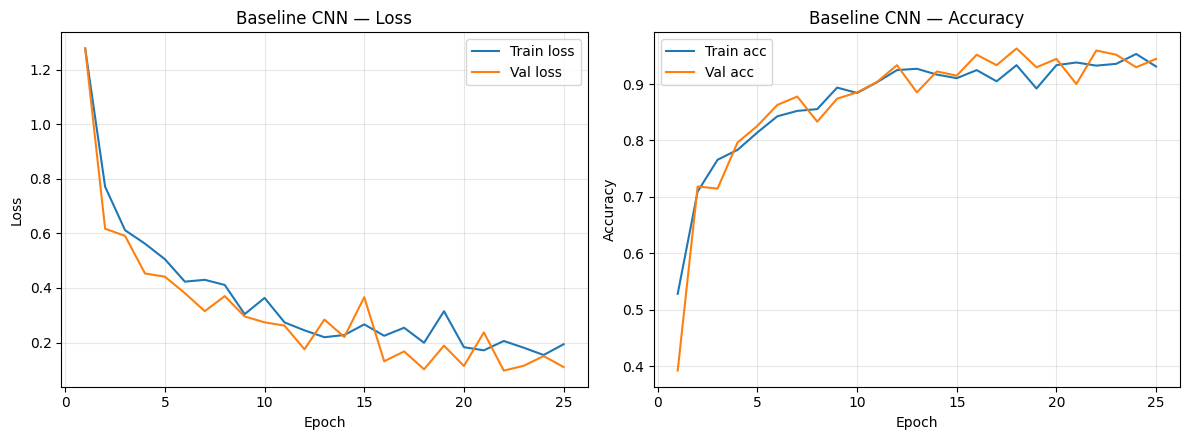

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history["epoch"], history["train_loss"], label="Train loss")
axes[0].plot(history["epoch"], history["val_loss"], label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Baseline CNN — Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["train_acc"], label="Train acc")
axes[1].plot(history["epoch"], history["val_acc"], label="Val acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Baseline CNN — Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/baseline_training_curves.png", dpi=150)
plt.show()


## 5. Evaluation on the held-out test set

Reports overall accuracy, per-class precision/recall/F1, and a confusion matrix — screenshot these
three outputs directly for the Task 2 deliverable.


In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
print(f"Baseline CNN — Test accuracy: {test_acc:.4f}  ({int(test_acc*len(all_labels))}/{len(all_labels)} correct)\n")

print("Classification report (precision / recall / F1 per class):\n")
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

with open("/content/baseline_classification_report.txt", "w") as f:
    f.write(f"Baseline CNN test accuracy: {test_acc:.4f}\n\n")
    f.write(report)


Baseline CNN — Test accuracy: 0.9481  (256/270 correct)

Classification report (precision / recall / F1 per class):

                 precision    recall  f1-score   support

        crazing     1.0000    0.9778    0.9888        45
      inclusion     0.8077    0.9333    0.8660        45
        patches     0.9783    1.0000    0.9890        45
 pitted_surface     0.9524    0.8889    0.9195        45
rolled-in_scale     1.0000    1.0000    1.0000        45
      scratches     0.9756    0.8889    0.9302        45

       accuracy                         0.9481       270
      macro avg     0.9523    0.9481    0.9489       270
   weighted avg     0.9523    0.9481    0.9489       270



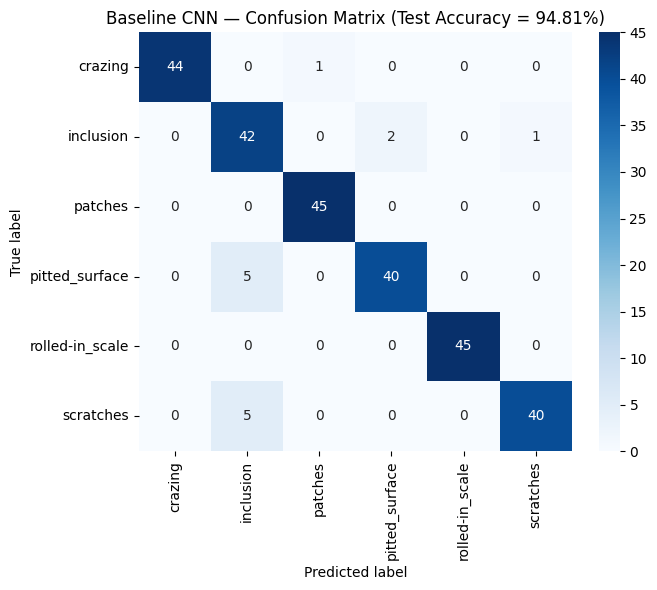

In [ ]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Baseline CNN — Confusion Matrix (Test Accuracy = {test_acc:.2%})")
plt.tight_layout()
plt.savefig("/content/baseline_confusion_matrix.png", dpi=150)
plt.show()


In [ ]:
# Per-class precision/recall/F1 as a tidy table (handy for pasting into the report)
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, labels=range(len(class_names)))

print(f"{'Class':16s} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>8}")
for i, cls in enumerate(class_names):
    print(f"{cls:16s} {precision[i]:10.4f} {recall[i]:8.4f} {f1[i]:8.4f} {support[i]:8d}")

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro")
print(f"\n{'Macro avg':16s} {macro_p:10.4f} {macro_r:8.4f} {macro_f1:8.4f}")


Class             Precision   Recall       F1  Support
crazing              1.0000   0.9778   0.9888       45
inclusion            0.8077   0.9333   0.8660       45
patches              0.9783   1.0000   0.9890       45
pitted_surface       0.9524   0.8889   0.9195       45
rolled-in_scale      1.0000   1.0000   1.0000       45
scratches            0.9756   0.8889   0.9302       45

Macro avg            0.9523   0.9481   0.9489


## 6. Save the baseline model and results

Saves the trained baseline weights and a JSON summary of key metrics — keep these for comparison
against the Week 3 transfer-learning model.


In [ ]:
torch.save(model.state_dict(), "/content/baseline_cnn.pt")

summary = {
    "model": "BaselineCNN (from scratch)",
    "num_params": n_params,
    "epochs_trained": history["epoch"][-1],
    "best_val_loss": best_val_loss,
    "test_accuracy": test_acc,
    "macro_precision": float(macro_p),
    "macro_recall": float(macro_r),
    "macro_f1": float(macro_f1),
    "class_names": class_names,
    "train_size": len(train_idx),
    "val_size": len(val_idx),
    "test_size": len(test_idx),
}
with open("/content/baseline_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("\nSaved: baseline_cnn.pt, baseline_summary.json, baseline_training_log.csv,"
      " baseline_training_curves.png, baseline_classification_report.txt, baseline_confusion_matrix.png")


{
  "model": "BaselineCNN (from scratch)",
  "num_params": 250182,
  "epochs_trained": 25,
  "best_val_loss": 0.09691532905454989,
  "test_accuracy": 0.9481481481481482,
  "macro_precision": 0.9523239809560065,
  "macro_recall": 0.9481481481481481,
  "macro_f1": 0.94892120057045,
  "class_names": [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
  ],
  "train_size": 1260,
  "val_size": 270,
  "test_size": 270
}

Saved: baseline_cnn.pt, baseline_summary.json, baseline_training_log.csv, baseline_training_curves.png, baseline_classification_report.txt, baseline_confusion_matrix.png


---
**For the Task 2 submission, include:**
1. The training log table/plot (Section 4) — shows the model is learning and not wildly over/under-fitting.
2. The final test accuracy and classification report (Section 5).
3. The confusion matrix image (Section 5) — discuss which defect classes get confused with each other and why (e.g. visually similar textures such as *rolled-in_scale* vs *patches*).
4. A one-paragraph comparison note once Week 3's transfer-learning model is trained, so the report shows baseline vs improved performance.


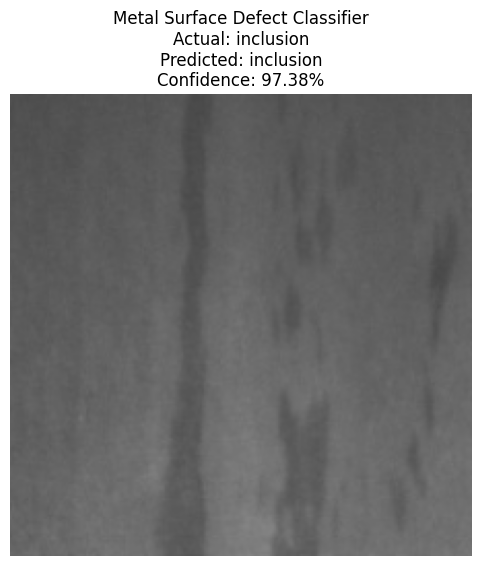

WORKING PROTOTYPE RESULT
Actual defect class    : inclusion
Predicted defect class : inclusion
Confidence             : 97.38%


In [ ]:
# ============================================================
# TASK 3 — WORKING PROTOTYPE DEMONSTRATION
# Metal Surface Defect Classifier
# ============================================================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

# Put the trained model into evaluation mode
model.eval()

# Select one random image from the held-out test set
sample_index = random.choice(test_idx)
image, true_label = base_dataset_eval_view[sample_index]

# Prepare image for the CNN
input_image = image.unsqueeze(0).to(DEVICE)

# Make prediction
with torch.no_grad():
    output = model(input_image)
    probabilities = F.softmax(output, dim=1)
    confidence, predicted_label = torch.max(probabilities, 1)

# Get class names
true_class = class_names[true_label]
predicted_class = class_names[predicted_label.item()]
confidence_percent = confidence.item() * 100

# Convert normalized image back to a displayable image
display_image = image.clone()

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

display_image = display_image * std + mean
display_image = display_image.clamp(0, 1)

# Display prototype result
plt.figure(figsize=(6, 6))
plt.imshow(display_image.permute(1, 2, 0))
plt.axis("off")

plt.title(
    f"Metal Surface Defect Classifier\n"
    f"Actual: {true_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence_percent:.2f}%"
)

plt.show()

# Print prototype result
print("=" * 50)
print("WORKING PROTOTYPE RESULT")
print("=" * 50)
print(f"Actual defect class    : {true_class}")
print(f"Predicted defect class : {predicted_class}")
print(f"Confidence             : {confidence_percent:.2f}%")
print("=" * 50)

Upload a steel surface image for defect classification:


Saving WhatsApp Image 2026-09-19 at 19.43.42 (1).jpeg to WhatsApp Image 2026-09-19 at 19.43.42 (1).jpeg


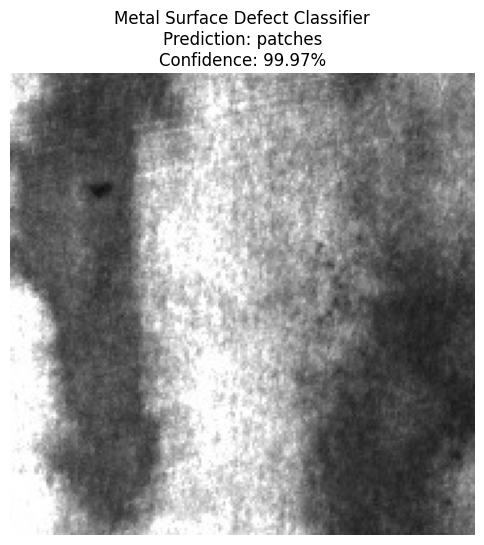

PROTOTYPE CLASSIFICATION RESULT
Uploaded image : WhatsApp Image 2026-09-19 at 19.43.42 (1).jpeg
Predicted class: patches
Confidence     : 99.97%


In [ ]:
# ============================================================
# TASK 3 — INTERACTIVE PROTOTYPE
# Upload a steel surface image and classify its defect
# ============================================================

from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import io

print("Upload a steel surface image for defect classification:")

# Open file picker
uploaded = files.upload()

for filename, file_data in uploaded.items():

    # Read uploaded image
    original_image = Image.open(io.BytesIO(file_data)).convert("RGB")

    # Apply the SAME preprocessing used for evaluation
    input_tensor = eval_transform(original_image).unsqueeze(0).to(DEVICE)

    # Run trained CNN
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_label = torch.max(probabilities, 1)

    predicted_class = class_names[predicted_label.item()]
    confidence_percent = confidence.item() * 100

    # Display uploaded image
    plt.figure(figsize=(6, 6))
    plt.imshow(original_image, cmap="gray")
    plt.axis("off")

    plt.title(
        f"Metal Surface Defect Classifier\n"
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence_percent:.2f}%"
    )

    plt.show()

    print("=" * 50)
    print("PROTOTYPE CLASSIFICATION RESULT")
    print("=" * 50)
    print(f"Uploaded image : {filename}")
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence     : {confidence_percent:.2f}%")
    print("=" * 50)

In [ ]:
# ============================================================
# DOWNLOAD ONE TEST IMAGE FOR THE LIVE DEMO
# ============================================================

from google.colab import files
from PIL import Image
import random

# Select one image from the held-out test set
demo_index = random.choice(test_idx)
demo_image, demo_label = base_dataset_eval_view[demo_index]

# Get its real class
demo_true_class = class_names[demo_label]

# Get the original image file path
demo_path, _ = base_dataset_eval_view.samples[demo_index]

print("Demo image selected")
print("Actual defect class:", demo_true_class)
print("File:", demo_path)

# Download it to the computer
files.download(demo_path)

Demo image selected
Actual defect class: pitted_surface
File: /content/NEU-CLS/pitted_surface/pitted_surface_107.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>